In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/household_energy_consumption - household_energy_consumption.csv")

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [8]:
df.tail()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
89995,H12857,2025-04-04,5.0,2,19.3,No,1.5
89996,H12857,2025-04-05,5.3,2,16.1,No,1.7
89997,H12857,2025-04-06,4.3,2,14.6,No,1.5
89998,H12857,2025-04-07,7.2,2,18.2,No,2.6
89999,H12857,2025-04-08,7.2,2,18.2,No,2.6


In [9]:
df.shape

(90000, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [11]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [12]:
df.dtypes

,0
Household_ID,object
Date,object
Energy_Consumption_kWh,float64
Household_Size,int64
Avg_Temperature_C,float64
Has_AC,object
Peak_Hours_Usage_kWh,float64


In [13]:
df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

In [14]:
df.isnull().sum()

,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


In [15]:
df=df.dropna()

In [16]:
x=df[["Household_Size", "Avg_Temperature_C", "Peak_Hours_Usage_kWh"]]
y=df["Energy_Consumption_kWh"]

In [17]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [18]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [19]:
model=LinearRegression()
model.fit(x_train_poly, y_train)

LinearRegression()

In [20]:
y_pred= model.predict(x_test_poly)

In [21]:
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=mse **0.5
r2=r2_score(y_test, y_pred)

In [22]:
print("\nPolynomial Regression Results")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)


Polynomial Regression Results
-----------------
MAE : 0.5592832525343422
MSE : 0.5132741174711
RMSE : 0.716431516246389
R2 : 0.9831459903864083


In [23]:
result=pd.DataFrame({
    "Actual Energy": y_test.values,
    "Predicted Energy": y_pred
})
print("\nActual vs Predicted:")
print(result.head(10))


Actual vs Predicted:
   Actual Energy  Predicted Energy
0           13.7         14.754917
1            7.3          7.626474
2           13.0         12.348609
3            9.0          8.556138
4           17.0         16.907604
5            9.9         10.114867
6            9.6          9.357839
7           10.0         10.212516
8           19.8         18.763752
9           13.0         13.533113


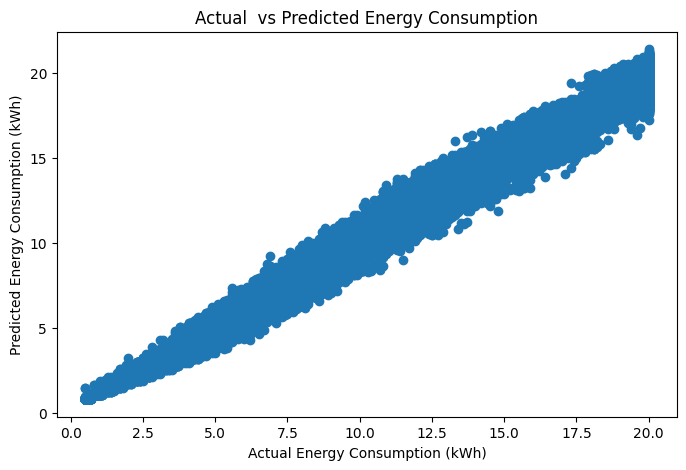

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title("Actual  vs Predicted Energy Consumption")
plt.show()